In [96]:
## Multiple Linear Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [97]:
df = pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [98]:
df.columns

Index(['Unnamed: 0', 'year', 'month', 'interest_rate', 'unemployment_rate',
       'index_price'],
      dtype='object')

In [99]:
df.drop(columns = ['Unnamed: 0', 'year', 'month'],axis=1, inplace=True)

In [100]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [101]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   interest_rate      24 non-null     float64
 1   unemployment_rate  24 non-null     float64
 2   index_price        24 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 708.0 bytes


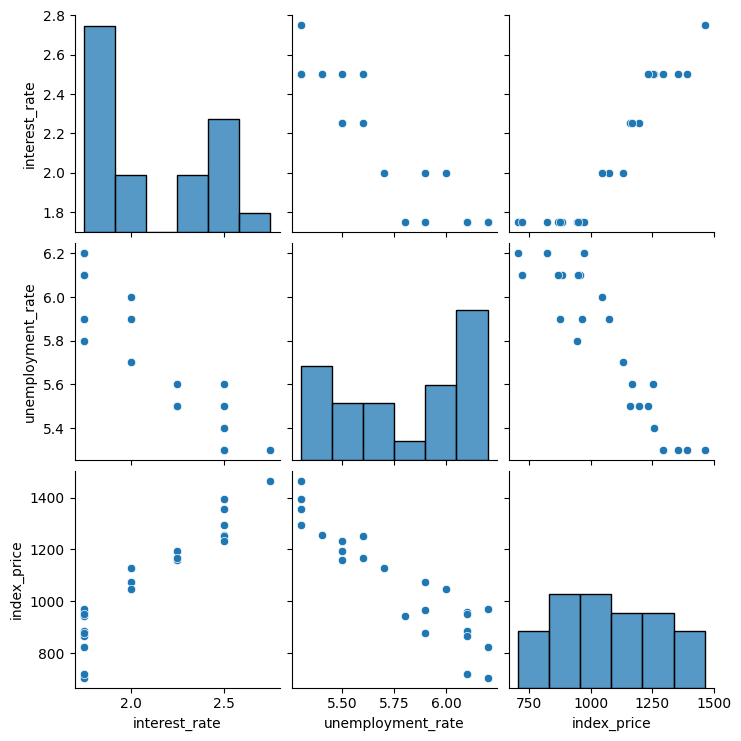

In [103]:
sns.pairplot(data=df)

<Axes: >

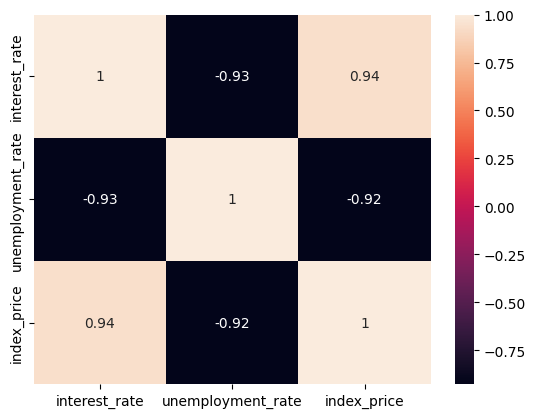

In [104]:

sns.heatmap(df.corr(), annot=True)

Text(0, 0.5, 'unemployment rate')

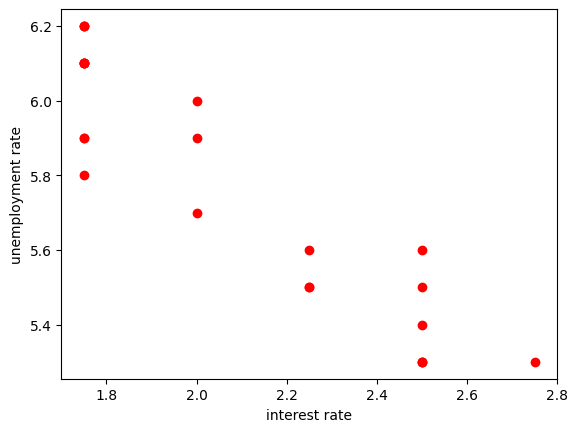

In [105]:
## analise the correlation more closely
plt.scatter(x=df['interest_rate'], y=df['unemployment_rate'], c='r')
plt.xlabel('interest rate')
plt.ylabel('unemployment rate')

In [106]:
## independent and dependent feature
X = df[['interest_rate', 'unemployment_rate']]
y = df['index_price']

In [107]:
X.shape

(24, 2)

In [108]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [109]:
X_train.shape

(18, 2)

<Axes: xlabel='interest_rate', ylabel='index_price'>

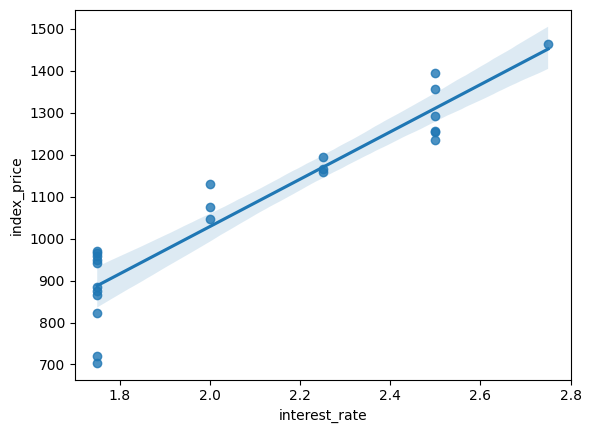

In [110]:
## Regression plot
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='interest_rate'>

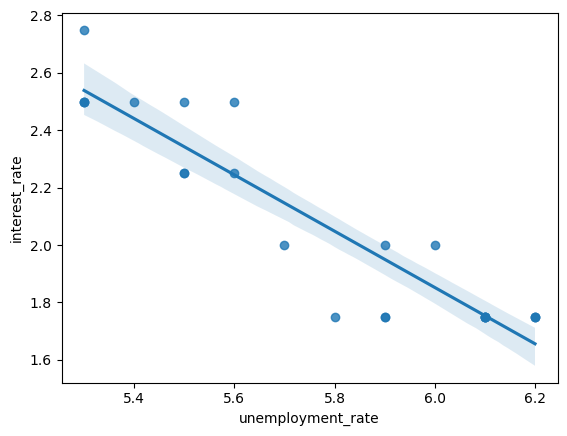

In [111]:
sns.regplot(x=df['unemployment_rate'], y=df['interest_rate'])

In [112]:
## standarization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [113]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [114]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [115]:
## cross validation
from sklearn.model_selection import cross_val_score
validation=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)
validation

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [116]:
np.mean(validation)

np.float64(-5914.828180162386)

In [117]:
## prediction
y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [118]:
## performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - score)*(len(y_test) - 1)/(len(y_test) - X_test.shape[1] - 1)

print('mean_squared_error', mse)
print('mean_absolute_error', mae)
print('root mean squared error', np.sqrt(mse))
print('r2 score',score)
print('Adjusted r2 score', adjusted_r2)

mean_squared_error 5793.762887712569
mean_absolute_error 59.935781523235484
root mean squared error 76.11677139574805
r2 score 0.8278978091457145
Adjusted r2 score 0.7131630152428576


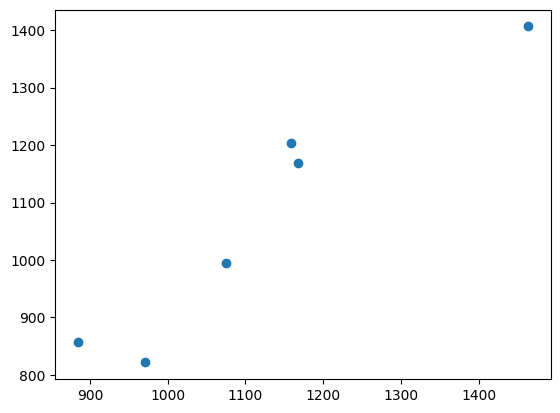

In [119]:
## Assumption
plt.scatter(y_test, y_pred)

In [120]:
residuals = y_test - y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


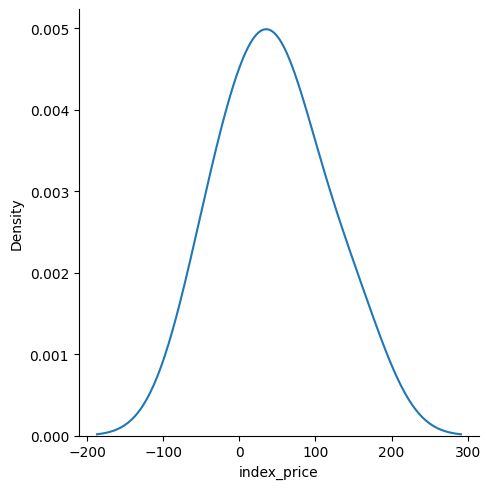

In [121]:
sns.displot(residuals, kind='kde')

In [124]:
## ols linear model
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [125]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 24 Dec 2025   Prob (F-statistic):                       0.754
Time:                        08:37:17   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""